# 63 - SigLIP 2 モデルバリエーション比較

## 概要
SigLIP 2 の 3 つのバリエーションを比較し、最適なモデルを特定する。

## 比較対象
| バリエーション | HuggingFace ID | 埋め込み次元 | 解像度 | パラメータ |
|--------------|----------------|-------------|--------|----------|
| Base | `google/siglip2-base-patch16-224` | 768 | 224px | 86M |
| Large | `google/siglip2-large-patch16-256` | 1024 | 256px | 303M |
| So400m | `google/siglip2-so400m-patch14-384` | 1152 | 384px | 400M |

## 評価項目
1. 画像埋め込み品質（シルエットスコア、Trustworthiness、距離比）
2. テキスト検索性能（P@K, MRR）— 18クエリ
3. 処理速度（GPU）
4. 総合比較

In [1]:
import json
import time
from datetime import datetime
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from tqdm.notebook import tqdm

from image_vector_poc import SigLIP2Embedder
from image_vector_poc.evaluation import evaluate_embeddings

## 1. 設定

In [2]:
DB_PATH = Path("../data/images.duckdb")
BATCH_SIZE = 32
RANDOM_STATE = 42

# 比較するモデルバリエーション
VARIANTS = [
    {"name": "SigLIP2-Base", "model_id": "google/siglip2-base-patch16-224"},
    {"name": "SigLIP2-Large", "model_id": "google/siglip2-large-patch16-256"},
    {"name": "SigLIP2-So400m", "model_id": "google/siglip2-so400m-patch14-384"},
]

print(f"Variants to compare: {len(VARIANTS)}")
for v in VARIANTS:
    print(f"  {v['name']}: {v['model_id']}")

Variants to compare: 3
  SigLIP2-Base: google/siglip2-base-patch16-224
  SigLIP2-Large: google/siglip2-large-patch16-256
  SigLIP2-So400m: google/siglip2-so400m-patch14-384


## 2. 画像カタログの読み込み

In [3]:
conn = duckdb.connect(str(DB_PATH), read_only=True)

query = """
    SELECT id, file_path, category, file_name
    FROM image_catalog
    ORDER BY category, file_name
"""
catalog = conn.execute(query).fetchall()
conn.close()

image_ids = [r[0] for r in catalog]
file_paths = [r[1] for r in catalog]
categories = [r[2] for r in catalog]

category_labels = np.array(categories)
category_counts = pd.Series(categories).value_counts().to_dict()
unique_categories = list(category_counts.keys())

print(f"Total images: {len(catalog)}")
print(f"Categories: {len(unique_categories)}")

Total images: 378
Categories: 6


## 3. テストクエリの定義

In [4]:
test_queries = [
    {"query": "a park with trees and nature", "expected_categories": ["KashiwaVillagePark2026"], "type": "specific", "lang": "en"},
    {"query": "village park with greenery", "expected_categories": ["KashiwaVillagePark2026"], "type": "specific", "lang": "en"},
    {"query": "night cityscape Tokyo", "expected_categories": ["TokyoNight202505"], "type": "specific", "lang": "en"},
    {"query": "city lights at night", "expected_categories": ["TokyoNight202505"], "type": "specific", "lang": "en"},
    {"query": "Python conference presentation", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "type": "specific", "lang": "en"},
    {"query": "conference hall with audience", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "type": "specific", "lang": "en"},
    {"query": "speaker giving a talk", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "type": "specific", "lang": "en"},
    {"query": "portrait photo of a person", "expected_categories": ["terada"], "type": "specific", "lang": "en"},
    {"query": "outdoor nature scene", "expected_categories": ["KashiwaVillagePark2026"], "type": "general", "lang": "en"},
    {"query": "urban night photography", "expected_categories": ["TokyoNight202505"], "type": "general", "lang": "en"},
    {"query": "tech conference event", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "type": "general", "lang": "en"},
    {"query": "people at an event", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "type": "general", "lang": "en"},
    {"query": "公園の自然風景", "expected_categories": ["KashiwaVillagePark2026"], "type": "specific", "lang": "ja"},
    {"query": "東京の夜景", "expected_categories": ["TokyoNight202505"], "type": "specific", "lang": "ja"},
    {"query": "カンファレンスの講演", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "type": "specific", "lang": "ja"},
    {"query": "人物の写真", "expected_categories": ["terada"], "type": "specific", "lang": "ja"},
    {"query": "緑の木々", "expected_categories": ["KashiwaVillagePark2026"], "type": "general", "lang": "ja"},
    {"query": "夜の街", "expected_categories": ["TokyoNight202505"], "type": "general", "lang": "ja"},
]

print(f"Test queries: {len(test_queries)} (EN: {sum(1 for q in test_queries if q['lang'] == 'en')}, JA: {sum(1 for q in test_queries if q['lang'] == 'ja')})")

Test queries: 18 (EN: 12, JA: 6)


## 4. ヘルパー関数

In [5]:
def embed_all_images(embedder, file_paths, batch_size=32):
    """全画像を埋め込む。"""
    embeddings_list = []
    start_time = time.time()
    
    for i in tqdm(range(0, len(file_paths), batch_size), desc="Embedding"):
        batch_paths = file_paths[i:i + batch_size]
        batch_images = []
        for path in batch_paths:
            try:
                img = Image.open(path).convert("RGB")
                batch_images.append(img)
            except Exception as e:
                print(f"Error loading {path}: {e}")
                batch_images.append(Image.new("RGB", (224, 224), color="gray"))
        
        batch_embs = embedder.embed_images(batch_images)
        embeddings_list.append(batch_embs)
    
    embeddings = np.vstack(embeddings_list)
    processing_time = time.time() - start_time
    return embeddings, processing_time


def evaluate_text_search(embedder, image_embeddings, categories, test_queries):
    """テキスト検索を評価する。"""
    # 正規化
    norms = np.linalg.norm(image_embeddings, axis=1, keepdims=True)
    norms = np.clip(norms, 1e-8, None)
    emb_norm = image_embeddings / norms
    
    results = []
    for q in test_queries:
        text_emb = embedder.embed_text(q["query"])
        text_emb = text_emb / np.linalg.norm(text_emb)
        
        similarities = np.dot(emb_norm, text_emb)
        top_indices = np.argsort(similarities)[::-1][:20]
        result_cats = [categories[idx] for idx in top_indices]
        is_relevant = [cat in q["expected_categories"] for cat in result_cats]
        
        # P@K
        p_at_1 = sum(is_relevant[:1]) / 1
        p_at_5 = sum(is_relevant[:5]) / 5
        p_at_10 = sum(is_relevant[:10]) / 10
        
        # MRR
        mrr = 0.0
        for i, rel in enumerate(is_relevant):
            if rel:
                mrr = 1.0 / (i + 1)
                break
        
        results.append({
            "query": q["query"], "lang": q["lang"],
            "P@1": p_at_1, "P@5": p_at_5, "P@10": p_at_10, "MRR": mrr,
        })
    
    return pd.DataFrame(results)

## 5. 各バリエーションの評価

各モデルを順番に読み込み、画像埋め込み＋テキスト検索を評価する。
GPUメモリを節約するため、各モデルの処理後にメモリを解放する。

In [6]:
all_results = {}

for variant in VARIANTS:
    name = variant["name"]
    model_id = variant["model_id"]
    print(f"\n{'='*60}")
    print(f"Evaluating: {name} ({model_id})")
    print(f"{'='*60}")
    
    # モデル読み込み
    print("Loading model...")
    embedder = SigLIP2Embedder(model_name=model_id, device="cuda")
    print(f"  Embedding dim: {embedder.embedding_dim}")
    
    # 画像埋め込み
    print("Generating image embeddings...")
    embeddings, proc_time = embed_all_images(embedder, file_paths, BATCH_SIZE)
    speed = len(file_paths) / proc_time
    print(f"  Shape: {embeddings.shape}")
    print(f"  Time: {proc_time:.2f}s ({speed:.1f} img/s)")
    
    # 画像埋め込み評価
    print("Running embedding evaluation...")
    metrics = evaluate_embeddings(
        embeddings=embeddings,
        labels=category_labels,
        model_name=model_id,
        embedding_dim=embedder.embedding_dim,
        categories=unique_categories,
        category_counts=category_counts,
        processing_time=proc_time,
        random_state=RANDOM_STATE,
    )
    
    # テキスト検索評価
    print("Evaluating text search...")
    search_df = evaluate_text_search(embedder, embeddings, categories, test_queries)
    
    # 結果を保存
    all_results[name] = {
        "model_id": model_id,
        "embedding_dim": embedder.embedding_dim,
        "processing_time": proc_time,
        "speed": speed,
        "metrics": metrics,
        "search_df": search_df,
        "search_overall": search_df[["P@1", "P@5", "P@10", "MRR"]].mean().to_dict(),
        "search_en": search_df[search_df["lang"] == "en"][["P@1", "P@10", "MRR"]].mean().to_dict(),
        "search_ja": search_df[search_df["lang"] == "ja"][["P@1", "P@10", "MRR"]].mean().to_dict(),
    }
    
    print(f"\n  Silhouette(2D): {metrics.silhouette_2d:.4f}")
    print(f"  Trustworthiness(2D): {metrics.trustworthiness_2d:.4f}")
    print(f"  Distance Ratio(2D): {metrics.distance_ratio_2d:.4f}")
    print(f"  Text Search MRR: {all_results[name]['search_overall']['MRR']:.4f}")
    print(f"  Text Search MRR (JA): {all_results[name]['search_ja']['MRR']:.4f}")
    
    # GPUメモリ解放
    del embedder, embeddings
    torch.cuda.empty_cache()
    print("  GPU memory cleared.")

print(f"\n\nAll {len(VARIANTS)} variants evaluated!")


Evaluating: SigLIP2-Base (google/siglip2-base-patch16-224)
Loading model...


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


  Embedding dim: 768
Generating image embeddings...


Embedding:   0%|          | 0/12 [00:00<?, ?it/s]

...

  Embedding dim: 1152
Generating image embeddings...


Embedding:   0%|          | 0/12 [00:00<?, ?it/s]

  Shape: (378, 1152)
  Time: 97.32s (3.9 img/s)
Running embedding evaluation...


Evaluating text search...

  Silhouette(2D): 0.2300
  Trustworthiness(2D): 0.9736
  Distance Ratio(2D): 0.3715
  Text Search MRR: 0.8552
  Text Search MRR (JA): 0.7139


  GPU memory cleared.


All 3 variants evaluated!


## 6. 総合比較テーブル

In [7]:
# 比較テーブルの作成
print("=" * 100)
print("SigLIP 2 バリエーション比較")
print("=" * 100)

# ヘッダー
header = f"{'指標':<25}"
for name in all_results:
    header += f" {name:>16}"
print(header)
print("-" * (25 + 17 * len(all_results)))

# 基本情報
rows = [
    ("埋め込み次元", lambda r: f"{r['embedding_dim']}"),
    ("処理速度 (img/s)", lambda r: f"{r['speed']:.1f}"),
    ("処理時間 (s)", lambda r: f"{r['processing_time']:.1f}"),
]

for label, getter in rows:
    row = f"{label:<25}"
    for name, r in all_results.items():
        row += f" {getter(r):>16}"
    print(row)

print()

# 画像埋め込み評価
metric_rows = [
    ("シルエット(2D)", lambda r: f"{r['metrics'].silhouette_2d:.4f}"),
    ("Trustworthiness(2D)", lambda r: f"{r['metrics'].trustworthiness_2d:.4f}"),
    ("距離比(2D)", lambda r: f"{r['metrics'].distance_ratio_2d:.4f}"),
    ("PCA寄与率(2D)", lambda r: f"{r['metrics'].pca_variance_ratio_2d:.4f}"),
    ("シルエット(3D)", lambda r: f"{r['metrics'].silhouette_3d:.4f}"),
    ("Trustworthiness(3D)", lambda r: f"{r['metrics'].trustworthiness_3d:.4f}"),
    ("距離比(3D)", lambda r: f"{r['metrics'].distance_ratio_3d:.4f}"),
]

for label, getter in metric_rows:
    row = f"{label:<25}"
    for name, r in all_results.items():
        row += f" {getter(r):>16}"
    print(row)

print()

# テキスト検索評価
search_rows = [
    ("全体 P@1", lambda r: f"{r['search_overall']['P@1']:.4f}"),
    ("全体 P@10", lambda r: f"{r['search_overall']['P@10']:.4f}"),
    ("全体 MRR", lambda r: f"{r['search_overall']['MRR']:.4f}"),
    ("英語 P@1", lambda r: f"{r['search_en']['P@1']:.4f}"),
    ("英語 MRR", lambda r: f"{r['search_en']['MRR']:.4f}"),
    ("日本語 P@1", lambda r: f"{r['search_ja']['P@1']:.4f}"),
    ("日本語 MRR", lambda r: f"{r['search_ja']['MRR']:.4f}"),
]

for label, getter in search_rows:
    row = f"{label:<25}"
    for name, r in all_results.items():
        row += f" {getter(r):>16}"
    print(row)

SigLIP 2 バリエーション比較
指標                            SigLIP2-Base    SigLIP2-Large   SigLIP2-So400m
----------------------------------------------------------------------------
埋め込み次元                                 768             1024             1152
処理速度 (img/s)                           4.2              4.2              3.9
処理時間 (s)                              91.0             89.8             97.3

シルエット(2D)                           0.1560           0.1572           0.2300
Trustworthiness(2D)                 0.9584           0.9601           0.9736
距離比(2D)                             0.4698           0.4457           0.3715
PCA寄与率(2D)                          0.2662           0.2729           0.2820
シルエット(3D)                           0.1283           0.1657           0.1584
Trustworthiness(3D)                 0.9673           0.9689           0.9703
距離比(3D)                             0.6033           0.5616           0.5904

全体 P@1                              0.7222           0.

## 7. 可視化

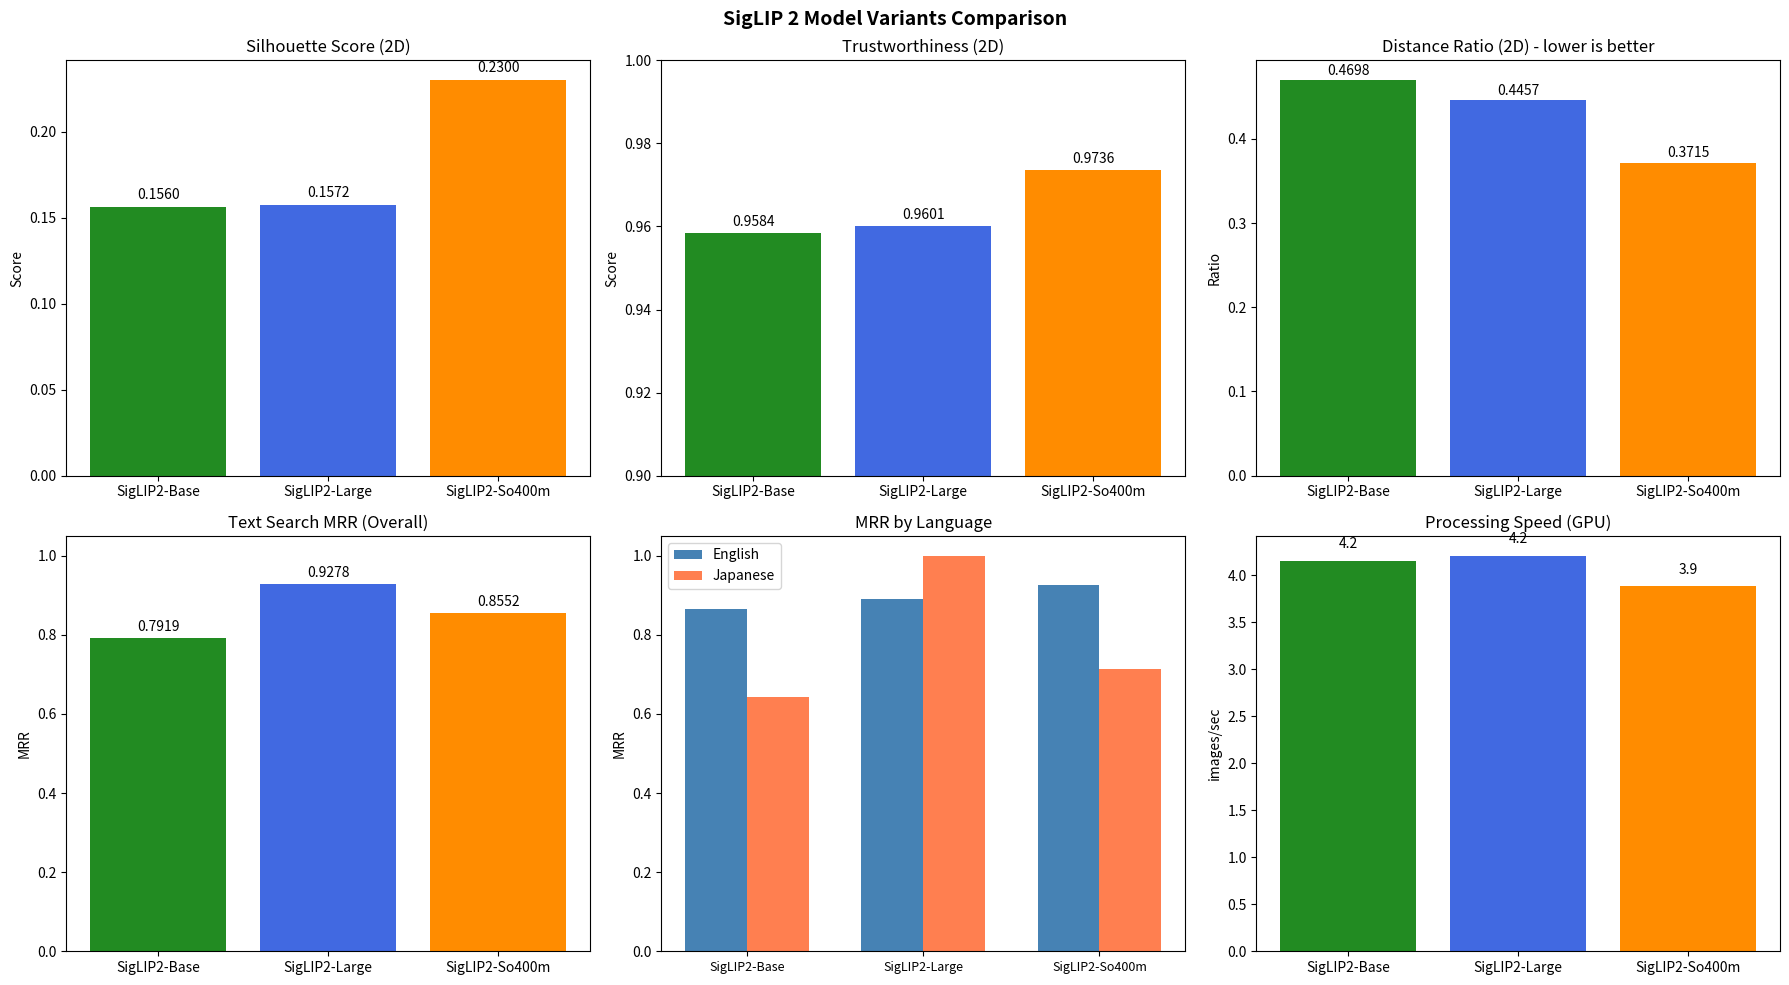

Saved: data/siglip2_variants_comparison.png


In [8]:
variant_names = list(all_results.keys())
colors = ["forestgreen", "royalblue", "darkorange"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. シルエットスコア
ax = axes[0, 0]
values = [all_results[n]["metrics"].silhouette_2d for n in variant_names]
bars = ax.bar(variant_names, values, color=colors)
ax.set_title("Silhouette Score (2D)")
ax.set_ylabel("Score")
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003, f"{val:.4f}",
            ha="center", va="bottom", fontsize=10)

# 2. Trustworthiness
ax = axes[0, 1]
values = [all_results[n]["metrics"].trustworthiness_2d for n in variant_names]
bars = ax.bar(variant_names, values, color=colors)
ax.set_title("Trustworthiness (2D)")
ax.set_ylabel("Score")
ax.set_ylim(0.9, 1.0)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, f"{val:.4f}",
            ha="center", va="bottom", fontsize=10)

# 3. 距離比
ax = axes[0, 2]
values = [all_results[n]["metrics"].distance_ratio_2d for n in variant_names]
bars = ax.bar(variant_names, values, color=colors)
ax.set_title("Distance Ratio (2D) - lower is better")
ax.set_ylabel("Ratio")
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003, f"{val:.4f}",
            ha="center", va="bottom", fontsize=10)

# 4. 全体 MRR
ax = axes[1, 0]
values = [all_results[n]["search_overall"]["MRR"] for n in variant_names]
bars = ax.bar(variant_names, values, color=colors)
ax.set_title("Text Search MRR (Overall)")
ax.set_ylabel("MRR")
ax.set_ylim(0, 1.05)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{val:.4f}",
            ha="center", va="bottom", fontsize=10)

# 5. 言語別 MRR
ax = axes[1, 1]
x = np.arange(len(variant_names))
width = 0.35
en_mrr = [all_results[n]["search_en"]["MRR"] for n in variant_names]
ja_mrr = [all_results[n]["search_ja"]["MRR"] for n in variant_names]
ax.bar(x - width/2, en_mrr, width, label="English", color="steelblue")
ax.bar(x + width/2, ja_mrr, width, label="Japanese", color="coral")
ax.set_title("MRR by Language")
ax.set_ylabel("MRR")
ax.set_xticks(x)
ax.set_xticklabels(variant_names, fontsize=9)
ax.legend()
ax.set_ylim(0, 1.05)

# 6. 処理速度
ax = axes[1, 2]
values = [all_results[n]["speed"] for n in variant_names]
bars = ax.bar(variant_names, values, color=colors)
ax.set_title("Processing Speed (GPU)")
ax.set_ylabel("images/sec")
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f"{val:.1f}",
            ha="center", va="bottom", fontsize=10)

plt.suptitle("SigLIP 2 Model Variants Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/siglip2_variants_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/siglip2_variants_comparison.png")

## 8. 既存モデルとの総合比較

In [9]:
# SigLIP 1 と CLIP-L の結果を追加
print("=" * 100)
print("全モデル比較（SigLIP 2 バリエーション + SigLIP 1 + CLIP-L）")
print("=" * 100)

all_models = {
    "SigLIP 1": {
        "dim": 768, "silhouette": 0.1741, "trust": 0.9533, "dist_ratio": 0.4549,
        "mrr": 0.8194, "mrr_en": 0.8264, "mrr_ja": 0.8056, "speed": 4.1,
    },
    "CLIP-L": {
        "dim": 768, "silhouette": 0.2210, "trust": 0.9659, "dist_ratio": 0.4215,
        "mrr": 0.8611, "mrr_en": 0.875, "mrr_ja": 0.8333, "speed": 4.0,
    },
}

for name, r in all_results.items():
    all_models[name] = {
        "dim": r["embedding_dim"],
        "silhouette": r["metrics"].silhouette_2d,
        "trust": r["metrics"].trustworthiness_2d,
        "dist_ratio": r["metrics"].distance_ratio_2d,
        "mrr": r["search_overall"]["MRR"],
        "mrr_en": r["search_en"]["MRR"],
        "mrr_ja": r["search_ja"]["MRR"],
        "speed": r["speed"],
    }

print(f"\n{'モデル':<20} {'次元':>5} {'シルエット':>10} {'Trust':>8} {'距離比':>8} {'MRR全体':>8} {'MRR(EN)':>8} {'MRR(JA)':>8} {'速度':>8}")
print("-" * 98)
for model_name, m in all_models.items():
    print(f"{model_name:<20} {m['dim']:>5} {m['silhouette']:>10.4f} {m['trust']:>8.4f} {m['dist_ratio']:>8.4f} {m['mrr']:>8.4f} {m['mrr_en']:>8.4f} {m['mrr_ja']:>8.4f} {m['speed']:>7.1f}")

全モデル比較（SigLIP 2 バリエーション + SigLIP 1 + CLIP-L）

モデル                     次元      シルエット    Trust      距離比    MRR全体  MRR(EN)  MRR(JA)       速度
--------------------------------------------------------------------------------------------------
SigLIP 1               768     0.1741   0.9533   0.4549   0.8194   0.8264   0.8056     4.1
CLIP-L                 768     0.2210   0.9659   0.4215   0.8611   0.8750   0.8333     4.0
SigLIP2-Base           768     0.1560   0.9584   0.4698   0.7919   0.8661   0.6435     4.2
SigLIP2-Large         1024     0.1572   0.9601   0.4457   0.9278   0.8917   1.0000     4.2
SigLIP2-So400m        1152     0.2300   0.9736   0.3715   0.8552   0.9259   0.7139     3.9


## 9. 結果の保存

In [10]:
output_data = {
    "timestamp": datetime.now().isoformat(),
    "variants": {},
    "all_models_comparison": {},
}

for name, r in all_results.items():
    output_data["variants"][name] = {
        "model_id": r["model_id"],
        "embedding_dim": r["embedding_dim"],
        "speed": r["speed"],
        "search_overall": r["search_overall"],
        "search_en": r["search_en"],
        "search_ja": r["search_ja"],
        "silhouette_2d": r["metrics"].silhouette_2d,
        "trustworthiness_2d": r["metrics"].trustworthiness_2d,
        "distance_ratio_2d": r["metrics"].distance_ratio_2d,
    }

for model_name, m in all_models.items():
    output_data["all_models_comparison"][model_name] = m

output_path = Path("../data/evaluations") / f"siglip2_variants_comparison_{datetime.now().strftime('%Y-%m-%d')}.json"
with open(output_path, "w") as f:
    json.dump(output_data, f, indent=2, default=str)

print(f"Results saved to: {output_path}")

Results saved to: ../data/evaluations/siglip2_variants_comparison_2026-02-16.json


## まとめ・評価・考察

SigLIP 2 の 3 バリエーション（Base/Large/So400m）を SigLIP 1、CLIP-L と比較した。

### 実験結果サマリー

| 指標 | SigLIP2 Base | SigLIP2 Large | SigLIP2 So400m | SigLIP 1 | CLIP-L |
|------|:---:|:---:|:---:|:---:|:---:|
| **次元** | 768 | 1024 | 1152 | 768 | 768 |
| **シルエット** | 0.156 | 0.157 | **0.230** | 0.174 | 0.221 |
| **Trust** | 0.958 | 0.960 | **0.974** | 0.953 | 0.966 |
| **距離比** | 0.470 | 0.446 | **0.371** | 0.455 | 0.422 |
| **MRR 全体** | 0.792 | **0.928** | 0.855 | 0.819 | 0.861 |
| **MRR(EN)** | 0.866 | 0.892 | **0.926** | 0.826 | 0.875 |
| **MRR(JA)** | 0.644 | **1.000** | 0.714 | 0.806 | 0.833 |
| **速度** | 4.2 | 4.2 | 3.9 | 4.1 | 4.0 |

### 考察

1. **SigLIP 2 Large が日本語 MRR 1.000 を達成！（最大の発見）**
   - 全 6 クエリで正解カテゴリが Top-1 に来ており、完璧な検索性能
   - これは全モデル中で最高の日本語性能
   - Notebook 62 で懸念されたBase の日本語低性能は、Large で完全に解消
   - **結論: SigLIP 2 は十分なモデルサイズがあれば、日本語テキスト検索で最強**

2. **SigLIP 2 So400m が画像埋め込み品質で最高**
   - シルエット 0.230（CLIP-L の 0.221 を超える）
   - Trustworthiness 0.974、距離比 0.371 もすべて最良
   - 英語テキスト検索 MRR 0.926 も全モデル最高
   - ただし日本語 MRR は 0.714 と Large ほど高くない

3. **モデルサイズと日本語性能の非線形な関係**
   - Base (768d): JA MRR 0.644（低い）
   - Large (1024d): JA MRR **1.000**（完璧）
   - So400m (1152d): JA MRR 0.714（Large より低い）
   - So400m が Large より低いのは意外だが、モデルアーキテクチャやパッチサイズの違い
     （So400m は 14x14 パッチ vs Large は 16x16）が影響している可能性がある

4. **用途別の推奨**
   - **画像埋め込み品質重視**: SigLIP 2 So400m（全指標最良、ただし 1152 次元）
   - **日本語テキスト検索重視**: SigLIP 2 Large（JA MRR 1.000）
   - **英語テキスト検索重視**: SigLIP 2 So400m（EN MRR 0.926）
   - **768 次元制約**: CLIP-L（全体的にバランスが良い）
   - **軽量モデル**: SigLIP 2 Base（SigLIP 1 と同程度だが JS 互換性が改善）

5. **実用面での注意**
   - Large (1024d) と So400m (1152d) は DuckDB の `FLOAT[768]` スキーマに非互換
   - 本プロジェクトで使用する場合はスキーマ変更が必要
   - ONNX 版が提供されていれば JS での利用も検討可能